# Week 7 Day 3 — Classification (Up / Down)

## Objective

Predict whether Reliance stock will go **UP** or **DOWN** on the next trading day.

### Topics
- Binary Classification
- Logistic Regression

### Tasks
- Convert target into binary
- Train Logistic Regression model
- Evaluate Accuracy
- Precision
- Recall
- F1 Score
- Plot Confusion Matrix

In [18]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use("ggplot")

## Load Dataset

In [19]:
# Load cleaned dataset

data = pd.read_csv("../Day01/ml_dataset.csv")

print(data.columns)

print(data.head())

Index(['Price', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_20',
       'RSI', 'MACD', 'Signal', 'Return', 'Lag_1', 'Lag_5', 'Lag_21',
       'Target'],
      dtype='object')
        Price              Close               High                Low  \
0      Ticker        RELIANCE.NS        RELIANCE.NS        RELIANCE.NS   
1        Date                NaN                NaN                NaN   
2  2020-01-31      628.599609375  647.1238564671794  626.6180767993984   
3  2020-02-03  616.9551391601562  623.3896651574961  606.9583015760081   
4  2020-02-04   635.167724609375  637.8840014691701  622.4323157911366   

                Open       Volume      SMA_10      SMA_20        RSI  \
0        RELIANCE.NS  RELIANCE.NS         NaN         NaN        NaN   
1                NaN          NaN         NaN         NaN        NaN   
2  647.0125063572486     34750310  666.229224  674.894650  25.145877   
3  610.0085691432375     30712290  659.690070  672.311942  24.072083   
4   623

## Create Binary Target

In [20]:
print(data.dtypes)

Price      object
Close      object
High       object
Low        object
Open       object
Volume     object
SMA_10    float64
SMA_20    float64
RSI       float64
MACD      float64
Signal    float64
Return    float64
Lag_1     float64
Lag_5     float64
Lag_21    float64
Target    float64
dtype: object


In [21]:
# Convert Close column to numeric

data["Close"] = pd.to_numeric(
    data["Close"],
    errors="coerce"
)

# Remove missing values

data = data.dropna(subset=["Close"])

In [22]:
# Next-day return

data["Target_Return"] = (
    data["Close"]
    .pct_change(fill_method=None)
    .shift(-1)
)

In [23]:
data["Target"] = np.where(
    data["Target_Return"] > 0,
    1,
    0
)

In [24]:
print(data[["Close", "Target_Return", "Target"]].head())

        Close  Target_Return  Target
2  628.599609      -0.018524       0
3  616.955139       0.029520       1
4  635.167725       0.015493       1
5  645.008667       0.006420       1
6  649.149902      -0.016566       0


In [25]:
# Next day return

data["Target_Return"] = data["Close"].pct_change().shift(-1)

# Binary target

data["Target"] = np.where(
    data["Target_Return"] > 0,
    1,
    0
)

## Select Features

In [26]:
features = [
    "SMA_10",
    "SMA_20",
    "RSI",
    "MACD",
    "Lag_1",
    "Lag_5",
    "Lag_21"
]

X = data[features]

y = data["Target"]

In [27]:
# Remove missing values

dataset = pd.concat([X, y], axis=1)

dataset = dataset.dropna()

X = dataset[features]

y = dataset["Target"]

print(X.shape)
print(y.shape)

(1215, 7)
(1215,)


## Train Test Split

In [28]:
tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

## Train Logistic Regression

In [29]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Evaluate Model

In [30]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Accuracy : 0.4752475247524752
Precision : 0.4715447154471545
Recall : 0.5858585858585859
F1 Score : 0.5225225225225225


## Confusion Matrix

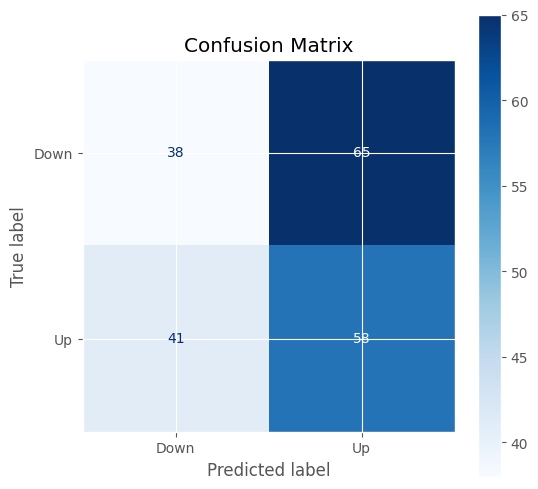

In [31]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Down","Up"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp.plot(ax=ax,cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig(
    "./confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Actual vs Predicted Classes

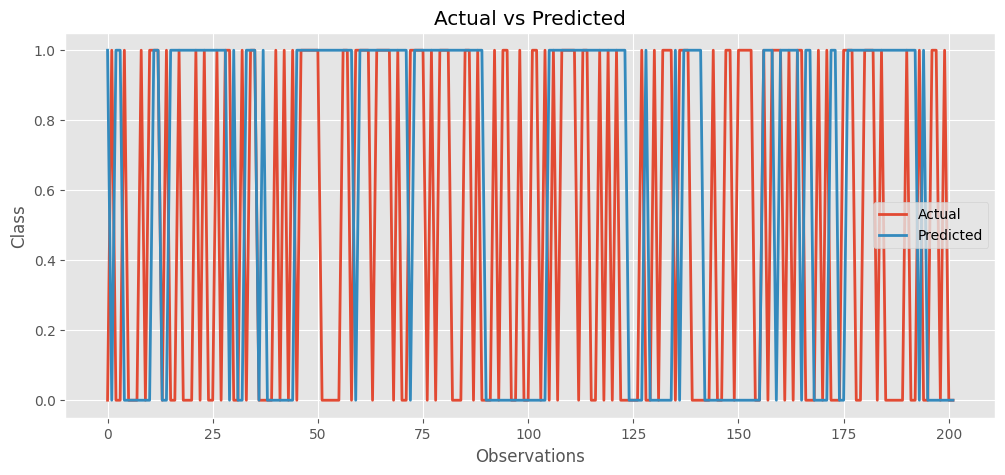

In [32]:
plt.figure(figsize=(12,5))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred,
    label="Predicted",
    linewidth=2
)

plt.title("Actual vs Predicted")

plt.xlabel("Observations")

plt.ylabel("Class")

plt.legend()

plt.grid(True)

plt.savefig(
    "./actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Interpretation

### Accuracy

Accuracy indicates the percentage of correctly classified stock movements.

### Precision

Precision measures how many predicted "UP" movements were actually correct.

### Recall

Recall measures how many actual "UP" movements were identified by the model.

### F1 Score

F1 Score balances Precision and Recall.

### Observation

The Logistic Regression model provides a simple baseline classifier for predicting stock direction. Although it is easy to interpret, stock prices are highly non-linear, so more advanced models may provide better predictive performance.